# Unit test analytical solution (AB2 from potentials.py)

We keep only the mechanics update used in `potentials.py`:

$$x_{n+1}=x_n+d_1v_{n+1}+d_2v_n,\quad d_1=1.5\Delta t,\; d_2=-0.5\Delta t.$$

Unit test setup: single cell, first-step impulse only,
\(\Delta t=0.1\) min, \(v_1=10\,\mu m/s=600\,\mu m/min\), and \(v_n=0\) for \(n\ge2\).

Closed-form response:

$$x_1=x_0+1.5\Delta t\cdot600=x_0+90\;\mu m,$$
$$x_2=x_1-0.5\Delta t\cdot600=x_0+60\;\mu m,$$
$$x_n=x_0+60\;\mu m\quad (n\ge2).$$

So AB2 gives one-step overshoot, then recoil to the stable displacement \(60\,\mu m\).

d1=0.150, d2=-0.050
positions (AB2): [0.0, 90.00000000000001, 60.000000000000014, 60.000000000000014]
positions (closed form): [0.0, 90.00000000000001, 60.0, 60.0]
final stable displacement: 60.000 um


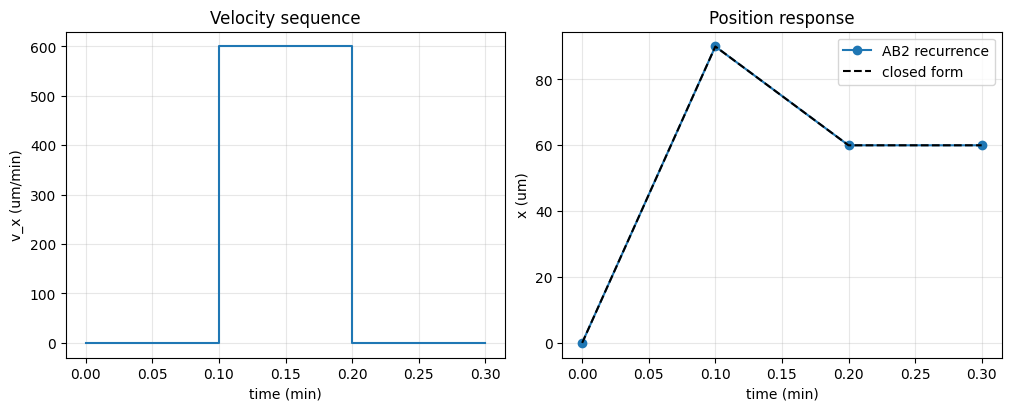

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Unit-test parameters
dt = 0.1            # min
x0 = 0.0            # um
v1 = 10.0 * 60.0    # um/min (10 um/s)

# AB2 coefficients from potentials.py
d1 = 1.5 * dt
d2 = -0.5 * dt

# Velocity sequence: impulse in first step only
v = np.array([0.0, v1, 0.0, 0.0], dtype=float)  # [v0, v1, v2, v3]
t = np.arange(len(v)) * dt

# AB2 recurrence
x = np.zeros_like(v)
x[0] = x0
for n in range(len(v) - 1):
    x[n + 1] = x[n] + d1 * v[n + 1] + d2 * v[n]

# Closed form for this specific impulse
x_cf = np.array([x0, x0 + 1.5*dt*v1, x0 + dt*v1, x0 + dt*v1], dtype=float)

print(f"d1={d1:.3f}, d2={d2:.3f}")
print(f"positions (AB2): {x.tolist()}")
print(f"positions (closed form): {x_cf.tolist()}")
print(f"final stable displacement: {x[-1]:.3f} um")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ax[0].step(t, v, where='post')
ax[0].set_title('Velocity sequence')
ax[0].set_xlabel('time (min)')
ax[0].set_ylabel('v_x (um/min)')
ax[0].grid(True, alpha=0.3)

ax[1].plot(t, x, 'o-', label='AB2 recurrence')
ax[1].plot(t, x_cf, 'k--', label='closed form')
ax[1].set_title('Position response')
ax[1].set_xlabel('time (min)')
ax[1].set_ylabel('x (um)')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.show()